# Anomaly Time Series 

## Introduction

The objective of this notebook is to show how to calculate and analyze anomaly time series for climate variables. An anomaly is the difference between the observed value and a climatological seasonal mean (which reflects predictable changes associated with annual solar heating, atmospheric circulation, ocean warming and cooling, and tropical convection):

$$
\text{anomaly} = \text{observed value} - \text{seasonal climatology}.
$$

Although this workflow can be applied to multiple climate variables, including zonal wind, sea surface temperature (SST), outgoing longwave radiation (OLR) and geopotential height, this notebook demonstrates the method using **850 hPa zonal wind** (commonly used to represent lower-tropospheric tropical circulation) from the NCEP–NCAR Reanalysis dataset. We calculate anomalies by removing the seasonal cycle using two approaches:

1. **Daily climatology** — subtracting the average value for each calendar day.
2. **Harmonic regression** — fitting and subtracting a smooth seasonal cycle using annual harmonics.

The resulting anomaly time series can then be inspected and compared to evaluate how each method removes the seasonal cycle through several steps:

1. Basic inspection
2. Compare time series at one grid point
3. Differences between two methods
4. Compare regional-mean anomaly time series
5. Check near-zero mean

Finally, Fourier analysis is applied to examine the dominant frequencies or periodic components present in the anomaly time series. This helps identify variability associated with different time scales.

---

## Download the NCEP-NCAR Reanalysis Data
First, we download 850-hPa zonal wind data (between 1979 and 2025) from the **NCEP-NCAR Reanalysis**, originally described by Kalnay et al. (1996).

### Imports
The data are accessed here as a preprocessed, cloud-hosted Zarr store from the Project Pythia cloud data bucket using `s3fs` and `xarray`. This preprocessed dataset allows the data to be opened directly from cloud storage without downloading the full dataset locally.

In [1]:
import s3fs
import xarray as xr
import numpy as np

# Create S3 filesystem
URL = 'https://js2.jetstream-cloud.org:8001/' #Locate and read a file
fs = s3fs.S3FileSystem(anon=True, client_kwargs=dict(endpoint_url=URL))

### Load Zonal Wind Data

Create mappers to the Zarr stores:

In [2]:
uwind_ncep_ncar_store = s3fs.S3Map(
    root=f'pythia/uwind-ncep-ncar.zarr',
    s3=fs,
    check=False
)

Create Xarray Datasets for uwind:

In [3]:
uwind_ncep_ncar = xr.open_zarr(uwind_ncep_ncar_store)
uwind_ncep_ncar

<xarray.Dataset> Size: 495MB
Dimensions:  (lat: 25, level: 2, lon: 144, time: 17167)
Coordinates:
  * lat      (lat) float32 100B 30.0 27.5 25.0 22.5 ... -22.5 -25.0 -27.5 -30.0
  * level    (level) float32 8B 850.0 200.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 137kB 1979-01-01 1979-01-02 ... 2025-12-31
Data variables:
    uwnd     (time, level, lat, lon) float32 494MB dask.array<chunksize=(1024, 2, 25, 144), meta=np.ndarray>

To quickly see what the zonal wind plot looks like (for instance, on Jan 1, 1979)

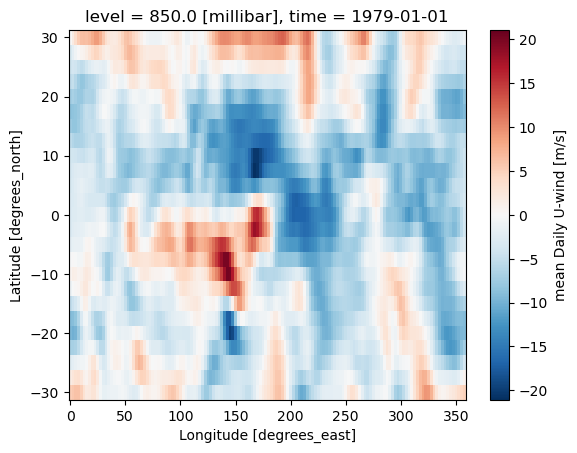

In [4]:
uwind_ncep_ncar.uwnd.isel(level=0, time=0).plot()

## Remove the Seasonal Cycle

### Daily Climatology

To isolate the intraseasonal and interannual signals we are interested in (e.g. the MJO), we first fit and subtract a smooth seasonal climatology at every grid point.

The traditional method of getting the anomalies is to compute a day-of-year mean (e.g. average all January 1sts, all January 2nds, …) and subtract that from the original time series.

In [5]:
def remove_seasonal_cycle_daily_climatology(da, drop_feb29=True):
    """
    Remove the seasonal cycle using traditional daily climatology.

    Parameters
    ----------
    da : xarray.DataArray
        Input data with a time dimension.
    drop_feb29 : bool
        If True, remove February 29 before computing anomalies.

    Returns
    -------
    anomalies : xarray.DataArray
        Data with daily climatological seasonal cycle removed.
    climatology : xarray.DataArray
        Daily climatology indexed by month_day.
    """

    # Create month-day coordinate, e.g. "01-01", "01-02", ...
    month_day = da["time"].dt.strftime("%m-%d")
    da = da.assign_coords(month_day=("time", month_day.data))

    # Optionally remove leap day
    if drop_feb29:
        da = da.where(da["month_day"] != "02-29", drop=True)

    # Compute daily climatology
    climatology = da.groupby("month_day").mean("time")

    # Subtract climatology from each matching calendar day
    anomalies = da.groupby("month_day") - climatology

    return anomalies, climatology

Apply this to 850 hPa zonal wind:

In [6]:
# Select the uwnd DataArray
uwind = uwind_ncep_ncar["uwnd"]

# Select 850 hPa
uwind_850_da = (
    uwind
    .sel(level=850)
    .drop_vars("level", errors="ignore")
)

# Remove the seasonal cycle using daily climatology
uwind_850_anomalies_daily_da, uwind_850_daily_clim = remove_seasonal_cycle_daily_climatology(
    uwind_850_da
)

# Update metadata
uwind_850_anomalies_daily_da.attrs = uwind_850_da.attrs.copy()
uwind_850_anomalies_daily_da.attrs["long_name"] = (
    uwind_850_da.attrs.get("long_name", "850 hPa zonal wind") + " anomalies"
)

# Convert anomalies to Dataset
uwind_850_anomalies_daily_ds = uwind_850_anomalies_daily_da.to_dataset(
    name="uwnd_anom"
)

uwind_850_anomalies_daily_ds

<xarray.Dataset> Size: 247MB
Dimensions:    (lat: 25, lon: 144, time: 17155)
Coordinates:
  * lat        (lat) float32 100B 30.0 27.5 25.0 22.5 ... -25.0 -27.5 -30.0
  * lon        (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 137kB 1979-01-01 1979-01-02 ... 2025-12-31
    month_day  (time) object 137kB '01-01' '01-02' '01-03' ... '12-30' '12-31'
Data variables:
    uwnd_anom  (time, lat, lon) float32 247MB dask.array<chunksize=(365, 25, 144), meta=np.ndarray>

## Harmonic Regression and Why Is It Better?

Harmonic regression has been covered in this [notebook](https://projectpythia.org/spectral-analysis-cookbook/notebooks/harmonic-anomalies/). The method with a small $N$ has two advantages:

- **Smoothness.** It produces a continuous, low-pass seasonal cycle and avoids the day-to-day noise of a raw daily climatology.
- **Robustness.** With only $2N + 1$ parameters per grid point, it is far less prone to overfitting short records.

Choosing $N = 4$ (`n_harmonics`) retains the annual, semi-annual, and the first two higher harmonics, which is enough to capture the main seasonal shape of tropical winds while filtering out higher-frequency noise that we want to keep in the anomalies.

### The model

For each grid point we model the time series $u(t)$ as a constant plus a sum of $N$ harmonics of the annual cycle:

$$
u(t) \approx a_0 + \sum_{k=1}^{N} \left[ a_k \sin(2\pi kt/T) + b_k \cos(2\pi kt/T) \right],
$$

where $T = 365.25$ days is the period of one year and $N$ (`n_harmonics`, default 4) controls how sharp the seasonal shape can be. The first harmonic ($k = 1$) is the pure annual cycle; $k = 2$ adds a semi-annual component; higher $k$ allow progressively narrower seasonal features.

In [7]:
def remove_seasonal_cycle_harmonic(data, n_harmonics=4, year_period=365.25):
    """
    Remove seasonal cycle using harmonic regression.
    
    Parameters:
    -----------
    data : ndarray
        3D array with shape (time, lat, lon). No NaN values.
    n_harmonics : int
        Number of harmonic pairs (sin/cos) to fit (default: 4)
    year_period : float
        Period of the seasonal cycle in time units (default: 365.25 days)
    
    Returns:
    --------
    anomalies : ndarray
        Data with seasonal cycle removed, same shape as input
    """

    n_time, n_lat, n_lon = data.shape
    data_2d = data.reshape(n_time, -1)

    # Build design matrix: 1 constant + n_harmonics sin/cos pairs
    t = np.arange(n_time)
    X = np.ones((n_time, 2 * n_harmonics + 1))
    for i in range(1, n_harmonics + 1):
        X[:, 2*i - 1] = np.sin(i * 2 * np.pi * t / year_period)
        X[:, 2*i] = np.cos(i * 2 * np.pi * t / year_period)

    # Solve via least squares and subtract seasonal component
    coeffs = np.linalg.lstsq(X, data_2d, rcond=None)[0]
    anomalies = data_2d - X @ coeffs

    return anomalies.reshape(n_time, n_lat, n_lon)

In [8]:
# Extract the 850 zonal winds
import dask
uwind_850 = dask.compute(uwind_ncep_ncar["uwnd"].sel(level=850).data)[0]

In [9]:
# Remove the seasonal cycle
uwind_850_anomalies = remove_seasonal_cycle_harmonic(uwind_850_da.values)

# Create a DataArray with the anomalies
uwind_850_anomalies_da = uwind_850_da.copy(
    data=uwind_850_anomalies
)

# Update attributes safely
uwind_850_anomalies_da.attrs["long_name"] = (
    uwind_850_da.attrs.get("long_name", "850 hPa zonal wind") + " anomalies"
)

# Convert to Dataset
uwind_850_anomalies_harmonic_ds = uwind_850_anomalies_da.to_dataset(
    name="uwnd_anom"
)

uwind_850_anomalies_harmonic_ds

<xarray.Dataset> Size: 495MB
Dimensions:    (lat: 25, lon: 144, time: 17167)
Coordinates:
  * lat        (lat) float32 100B 30.0 27.5 25.0 22.5 ... -25.0 -27.5 -30.0
  * lon        (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 137kB 1979-01-01 1979-01-02 ... 2025-12-31
Data variables:
    uwnd_anom  (time, lat, lon) float64 494MB 1.142 2.934 4.368 ... 8.243 4.796

## Inspect the Anomaly Time Series

After computing anomalies with both methods, we compare their behavior at individual grid points and over a regional average. And then we check if the anomalies have near-zero mean. 

Let's see what the figures look like for both daily climatology and harmonic regression methods for one day (in this case, Jan 11, 1979).

First of all, let's extract the variables since they are stored in the dataset: 

In [10]:
daily_anom = uwind_850_anomalies_daily_ds["uwnd_anom"]
harmonic_anom = uwind_850_anomalies_harmonic_ds["uwnd_anom"]

### I. Basic Inspection
Let's see what zonal wind pattern looks like on Jan 11, 1979 for both methods. 

### Daily Climatology

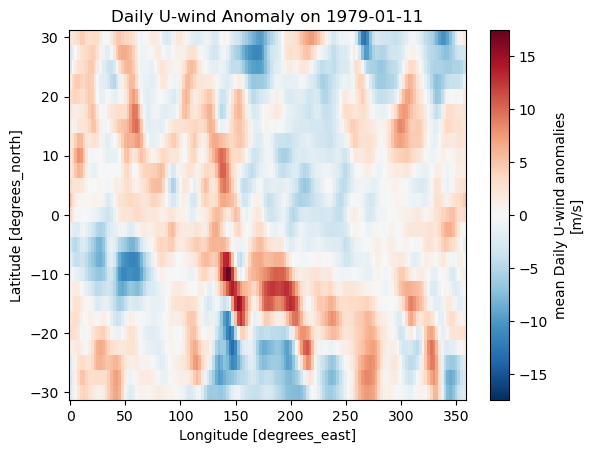

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

da_plot = daily_anom.isel(time=10)
time_value = pd.to_datetime(da_plot.time.values)

fig, ax = plt.subplots()

da_plot.plot(ax=ax)

ax.set_title(f"Daily 850 hPa Zonal Wind Anomaly on {time_value:%Y-%m-%d}")

plt.show()


### Harmonic Regression

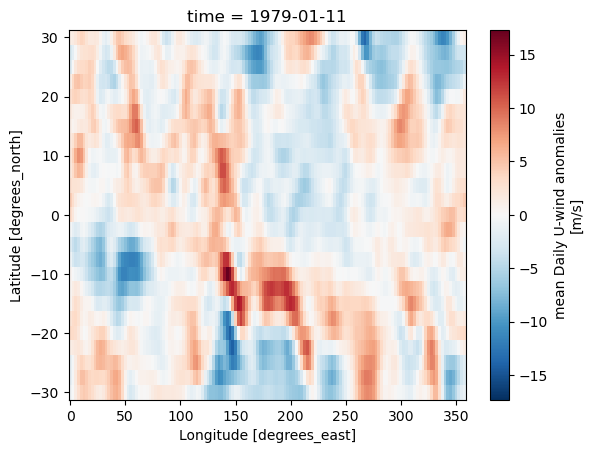

In [12]:
harmonic_anom.isel(time=10).plot()

### II. Compare Time Series at One Grid Point

Then we compare them at one grid point (lat=0, lon=180):

In [13]:
lat_select = 0.0
lon_select = 180.0

daily_point = daily_anom.sel(lat=lat_select, lon=lon_select, method="nearest")
harmonic_point = harmonic_anom.sel(lat=lat_select, lon=lon_select, method="nearest")

Then we plot the time series:

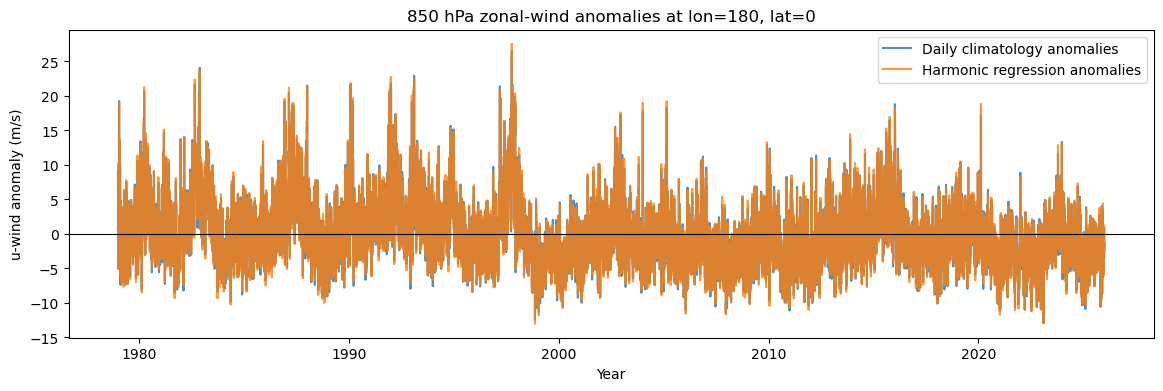

In [14]:
plt.figure(figsize=(14, 4))

daily_point.plot(label="Daily climatology anomalies", alpha=0.8)
harmonic_point.plot(label="Harmonic regression anomalies", alpha=0.8)

plt.axhline(0, color="k", linewidth=0.8)
plt.title("850 hPa zonal-wind anomalies at lon=180, lat=0")
plt.xlabel("Year")
plt.ylabel("u-wind anomaly (m/s)")
plt.legend()
plt.show()

And if you want to zoom into a shorter time period, say, between 2000 and 2003:

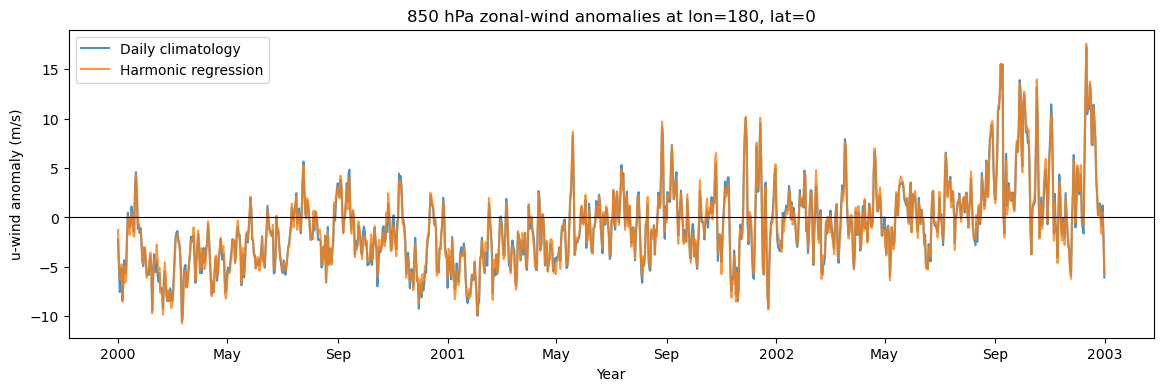

In [15]:
plt.figure(figsize=(14, 4))

daily_point.sel(time=slice("2000-01-01", "2002-12-31")).plot(
    label="Daily climatology", alpha=0.8
)
harmonic_point.sel(time=slice("2000-01-01", "2002-12-31")).plot(
    label="Harmonic regression", alpha=0.8
)

plt.axhline(0, color="k", linewidth=0.8)
plt.title("850 hPa zonal-wind anomalies at lon=180, lat=0")
plt.xlabel("Year")
plt.ylabel("u-wind anomaly (m/s)")
plt.legend()
plt.show()

### III. Differences Between Two Methods

If you are curious about the difference between two methods:

In [16]:
daily_aligned, harmonic_aligned = xr.align(daily_anom, harmonic_anom, join="inner")

difference = daily_aligned - harmonic_aligned

:::{note}
Align in case one method dropped Feb 29 or has slightly different times.
:::

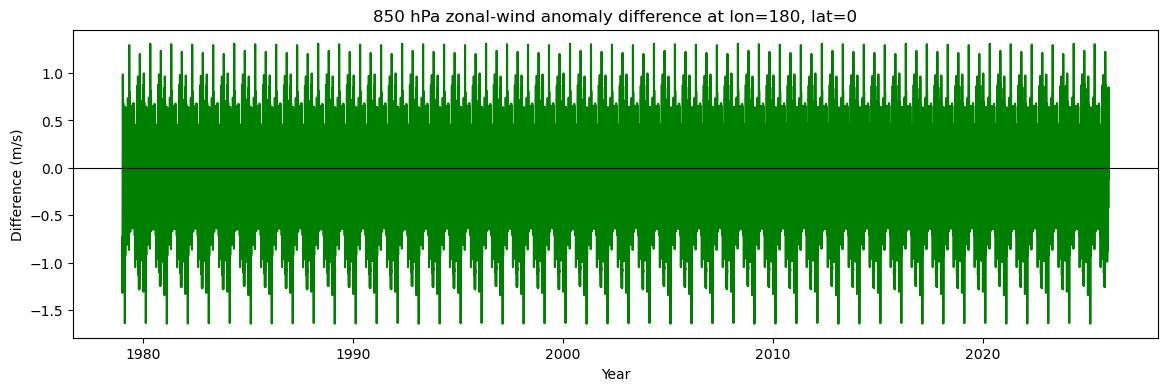

In [17]:
difference_point = difference.sel(lat=lat_select, lon=lon_select, method="nearest")

plt.figure(figsize=(14, 4))
difference_point.plot(color="green")
plt.axhline(0, color="k", linewidth=0.8)
plt.xlabel("Year")
plt.ylabel("Difference (m/s)")
plt.title("850 hPa zonal-wind anomaly difference at lon=180, lat=0")
plt.show()

For a shorter time period (between 2020 and 2025): 

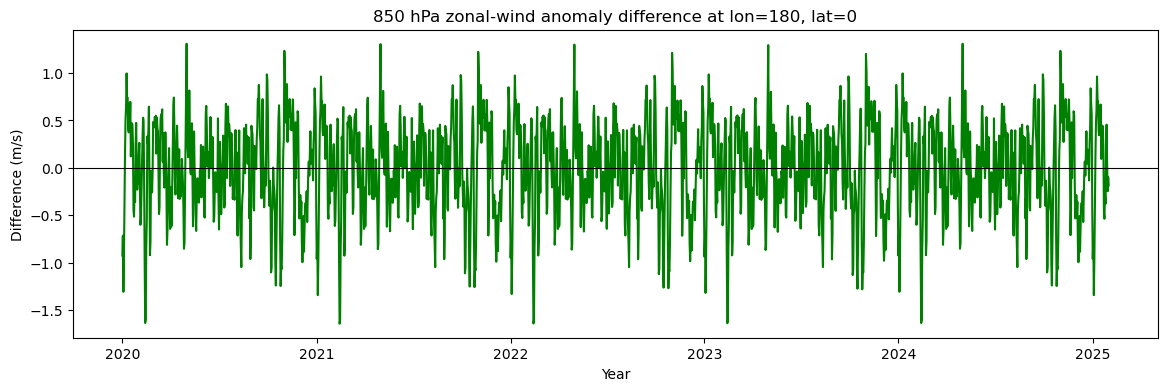

In [18]:
difference_point = difference.sel(lat=lat_select, lon=lon_select, method="nearest")
difference_point_sub = difference_point.sel(time=slice("2020-01", "2025-01"))

plt.figure(figsize=(14, 4))
difference_point_sub.plot(color="green")
plt.axhline(0, color="k", linewidth=0.8)
plt.xlabel("Year")
plt.ylabel("Difference (m/s)")
plt.title("850 hPa zonal-wind anomaly difference at lon=180, lat=0")
plt.show()

### IV. Compare regional-mean anomaly time series

For tropical wind analysis, it is often useful to average over the tropical latitude band, commonly defined as 30°S–30°N. In this dataset, the latitude range is already limited to 30°S–30°N. However, if using a global dataset, the tropical region should first be selected before computing the tropical mean.

In [19]:
daily_tropics = daily_aligned.sel(lat=slice(30, -30))
harmonic_tropics = harmonic_aligned.sel(lat=slice(30, -30))

Compute cosine-latitude weights:

In [20]:
weights = np.cos(np.deg2rad(daily_tropics["lat"]))

Area-weighted tropical mean:

In [21]:
daily_tropical_mean = daily_tropics.weighted(weights).mean(("lat", "lon"))
harmonic_tropical_mean = harmonic_tropics.weighted(weights).mean(("lat", "lon"))

Plot:

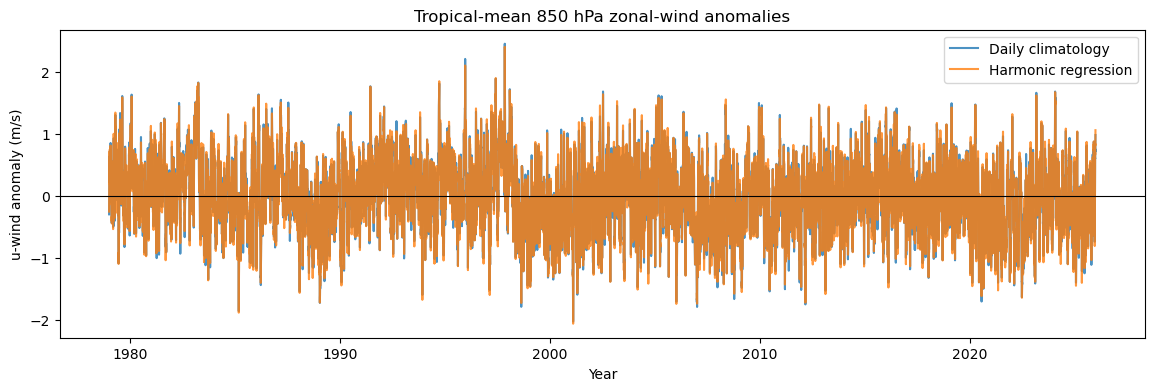

In [42]:
plt.figure(figsize=(14, 4))

daily_tropical_mean.plot(label="Daily climatology", alpha=0.8)
harmonic_tropical_mean.plot(label="Harmonic regression", alpha=0.8)

plt.axhline(0, color="k", linewidth=0.8)
plt.title("Tropical-mean 850 hPa zonal-wind anomalies")
plt.xlabel("Year")
plt.ylabel("u-wind anomaly (m/s)")
plt.legend()
plt.show()

### V. Check that the anomalies have near-zero mean

Ideally, both time mean maps should be close to zero. 

In [23]:
daily_mean = daily_aligned.mean("time")
harmonic_mean = harmonic_aligned.mean("time")

Plot:

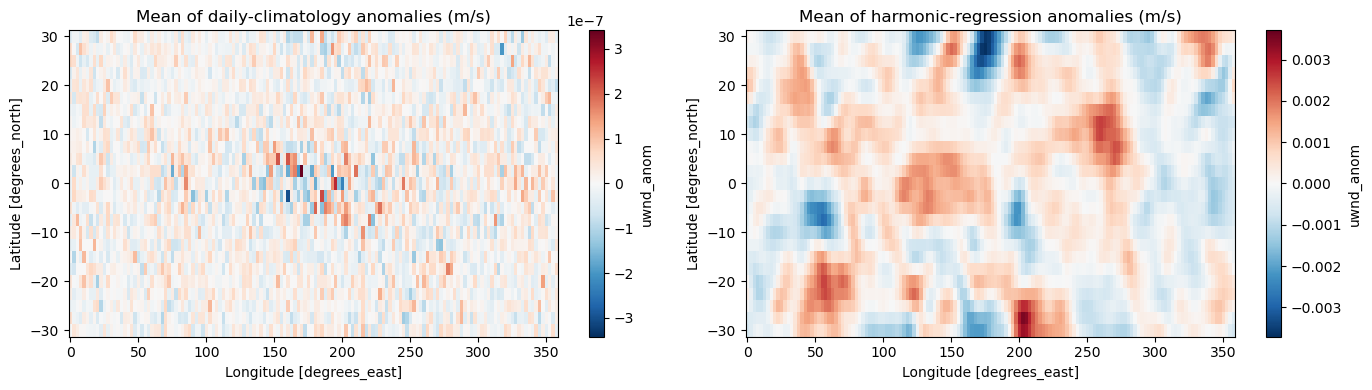

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

daily_mean.plot(ax=axes[0], cmap="RdBu_r")
axes[0].set_title("Mean of daily-climatology anomalies (m/s)")

harmonic_mean.plot(ax=axes[1], cmap="RdBu_r")
axes[1].set_title("Mean of harmonic-regression anomalies (m/s)")

plt.tight_layout()
plt.show()

Since the order of magnitude for both is way less than 1, it shows that both anomalies have near-zero mean. 

## Fourier Analysis

In this section, we use Fourier Analysis to examine the dominant periodic components in the tropical 850 hPa zonal wind time series. For more details regarding Harmoninc Ananlysis of the Seasonal Cycle, the audience can read [this notebook](https://projectpythia.org/spectral-analysis-cookbook/notebooks/harmonic-analysis/). 

### Prepare 850 hPa Zonal Wind Data

The original dataset is daily, but for this part of the analysis we convert the data to monthly means. Monthly averaging reduces high-frequency day-to-day variability and makes it easier to examine the seasonal cycle and lower-frequency variability.

In [25]:
# Convert daily data to monthly means
uwind_850_monthly = uwind_850_da.resample(time="MS").mean()

### Select a Representative Grid Point

To inspect the time series more closely, we select one representative grid point. Because the exact latitude and longitude values may not exist in the gridded dataset, we use `method="nearest"` to select the closest available grid point.

The map below shows the monthly mean 850 hPa zonal wind for the first time step, with the selected grid point marked in red.

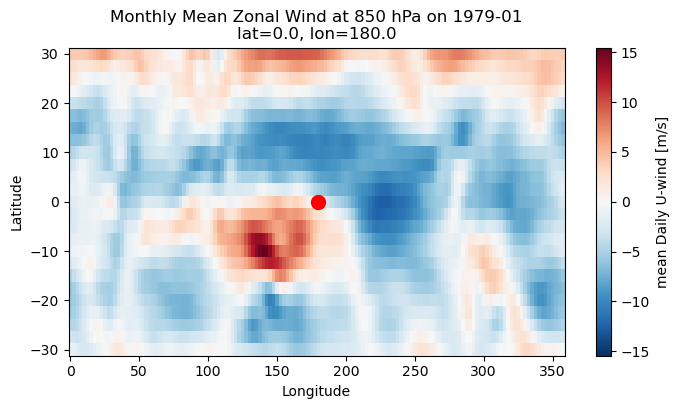

In [26]:
uwind_850_series = uwind_850_monthly.sel(
    lat=lat_select, lon=lon_select, method="nearest"
)

time_value = pd.to_datetime(uwind_850_monthly.time[0].values)

fig, ax = plt.subplots(figsize=(8, 4))
uwind_850_monthly[0].plot(ax=ax)
ax.plot(lon_select, lat_select, "ro", markersize=10)
ax.set_title(
    f"Monthly Mean Zonal Wind at 850 hPa on {time_value:%Y-%m}\n"
    f"lat={lat_select}, lon={lon_select}"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

### Inspect the Monthly Mean Time Series

Here, we plot the full monthly mean 850 hPa zonal wind time series at the selected grid point. This allows us to visually inspect the variability in the original data before removing the seasonal cycle.

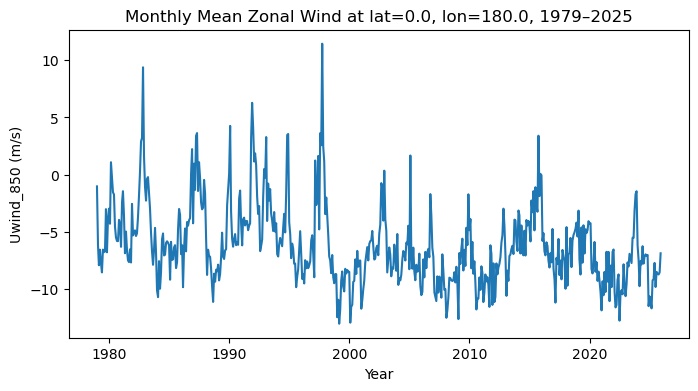

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
uwind_850_series.plot(ax=ax)
ax.set_title(
    f"Monthly Mean Zonal Wind at lat={lat_select}, lon={lon_select}, "
    f"{1979}–{2025}"
)
ax.set_xlabel("Year")
ax.set_ylabel("Uwind_850 (m/s)")
plt.show()

### Compute the Monthly Climatology

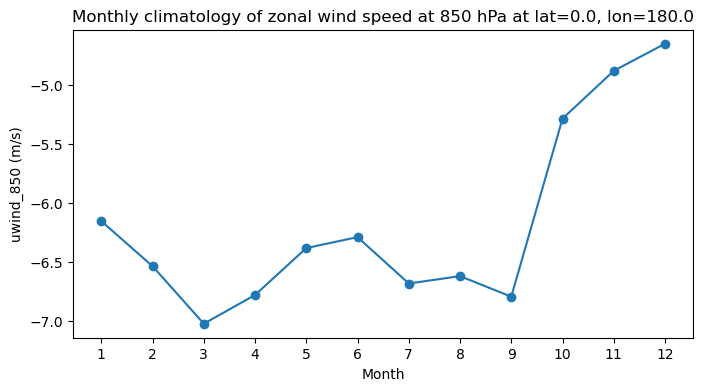

In [28]:
uwind_850_monthly_climatology = uwind_850_series.groupby("time.month").mean("time")

fig, ax = plt.subplots(figsize=(8, 4))
uwind_850_monthly_climatology.plot(ax=ax, marker="o")
ax.set_title(
    f"Monthly climatology of zonal wind speed at 850 hPa at lat={lat_select}, lon={lon_select}"
)
ax.set_xlabel("Month")
ax.set_ylabel("uwind_850 (m/s)")
ax.set_xticks(np.arange(1, 13))
plt.show()

In [29]:
def remove_seasonal_cycle_monthly_climatology(da):
    """
    Remove the seasonal cycle using monthly climatology.

    Parameters
    ----------
    da : xarray.DataArray
        Input monthly data with a time dimension.

    Returns
    -------
    anomalies : xarray.DataArray
        Monthly anomalies with the monthly climatological seasonal cycle removed.

    climatology : xarray.DataArray
        Monthly climatology indexed by month.
    """

    # Compute monthly climatology: Jan mean, Feb mean, ..., Dec mean
    climatology = da.groupby("time.month").mean("time")

    # Remove corresponding monthly climatology from each time step
    anomalies = da.groupby("time.month") - climatology

    return anomalies, climatology

In [30]:
# Remove the seasonal cycle using monthly climatology
uwind_850_anomalies_monthly_da, uwind_850_monthly_clim = (
    remove_seasonal_cycle_monthly_climatology(uwind_850_monthly)
)

# Update metadata
uwind_850_anomalies_monthly_da.attrs = uwind_850_da.attrs.copy()
uwind_850_anomalies_monthly_da.attrs["long_name"] = (
    uwind_850_da.attrs.get("long_name", "850 hPa zonal wind")
    + " monthly anomalies"
)

uwind_850_anomalies_monthly_da.attrs["description"] = (
    "Monthly anomalies computed by removing the monthly climatological seasonal cycle"
)


### Remove the Seasonal Cycle Using Harmonic Regression

In [31]:
def remove_seasonal_cycle_harmonic_monthly(data, n_harmonics=4, year_period=12):
    """
    Remove seasonal cycle from monthly data using harmonic regression.

    Parameters
    ----------
    data : ndarray
        3D array with shape (time, lat, lon). Time axis should be monthly.
    n_harmonics : int
        Number of harmonic pairs to fit.
    year_period : float
        Period of the seasonal cycle in months. For monthly data, use 12.

    Returns
    -------
    anomalies : ndarray
        Data with seasonal cycle removed, same shape as input.
    """

    n_time, n_lat, n_lon = data.shape
    data_2d = data.reshape(n_time, -1)

    # Time index in months
    t = np.arange(n_time)

    # Design matrix: constant + sin/cos harmonic pairs
    X = np.ones((n_time, 2 * n_harmonics + 1))

    for i in range(1, n_harmonics + 1):
        X[:, 2*i - 1] = np.sin(2 * np.pi * i * t / year_period)
        X[:, 2*i]     = np.cos(2 * np.pi * i * t / year_period)

    # Least-squares fit
    coeffs = np.linalg.lstsq(X, data_2d, rcond=None)[0]

    # Remove fitted seasonal cycle
    anomalies = data_2d - X @ coeffs

    return anomalies.reshape(n_time, n_lat, n_lon)

In [32]:
uwind_850_monthly_harmonic_anom_values = remove_seasonal_cycle_harmonic_monthly(
    uwind_850_monthly.values,
    n_harmonics=4,
    year_period=12
)

# Save it as an xarray DataArray
uwind_850_monthly_harmonic_anom = xr.DataArray(
    uwind_850_monthly_harmonic_anom_values,
    coords=uwind_850_monthly.coords,
    dims=uwind_850_monthly.dims,
    name="uwind_850_anom"
)

### Extract Anomaly Time Series at the Selected Grid Point

In [33]:
monthly_harmonic_point = uwind_850_monthly_harmonic_anom.sel(lat=lat_select, lon=lon_select, method="nearest")
monthly_climatology_point = uwind_850_anomalies_monthly_da.sel(lat=lat_select, lon=lon_select, method="nearest")

### Fourier Analysis of the Anomalies

Here we apply the Fourier transform to the anomaly time series to examine which periods explain the most variance.

Because the data are monthly, the sampling interval is 1 month. Before applying the Fourier transform, we remove the time mean from the anomaly series. This avoids concentrating power at the zero-frequency component.

#### Monthly Climatology

In [34]:
sampling_interval = 1
monthly_climatology_mean = np.mean(monthly_climatology_point.values)

monthly_climatology_anomalies = (
    monthly_climatology_point.values - monthly_climatology_mean
)

monthly_climatology_frequencies = np.fft.fftfreq(
    len(monthly_climatology_anomalies),
    d=sampling_interval
)

monthly_climatology_periods = 1 / monthly_climatology_frequencies

/tmp/ipykernel_131/196557812.py:13: RuntimeWarning: divide by zero encountered in divide
  monthly_climatology_periods = 1 / monthly_climatology_frequencies


In [35]:
monthly_climatology_fourier_coefficients = np.fft.fft(
    monthly_climatology_anomalies
)

monthly_climatology_amplitudes = np.abs(
    monthly_climatology_fourier_coefficients
)
    
monthly_climatology_power = monthly_climatology_amplitudes ** 2

monthly_climatology_variance = np.var(monthly_climatology_anomalies)

monthly_climatology_normalized_power = (
    monthly_climatology_power / np.sum(monthly_climatology_power)
) * monthly_climatology_variance

monthly_climatology_percent_variance = (
    monthly_climatology_normalized_power / monthly_climatology_variance
) * 100.0

#### Harmonic Regression

In [36]:
sampling_interval = 1
monthly_harmonic_mean = np.mean(monthly_harmonic_point.values)

monthly_harmonic_anomalies = (
    monthly_harmonic_point.values - monthly_harmonic_mean
)

monthly_harmonic_frequencies = np.fft.fftfreq(
    len(monthly_harmonic_anomalies),
    d=sampling_interval
)

monthly_harmonic_periods = 1 / monthly_harmonic_frequencies

/tmp/ipykernel_131/219631236.py:13: RuntimeWarning: divide by zero encountered in divide
  monthly_harmonic_periods = 1 / monthly_harmonic_frequencies


In [37]:
monthly_harmonic_fourier_coefficients = np.fft.fft(
    monthly_harmonic_anomalies
)

monthly_harmonic_amplitudes = np.abs(
    monthly_harmonic_fourier_coefficients
)
    
monthly_harmonic_power = monthly_harmonic_amplitudes ** 2

monthly_harmonic_variance = np.var(monthly_harmonic_anomalies)

monthly_harmonic_normalized_power = (
    monthly_harmonic_power / np.sum(monthly_harmonic_power)
) * monthly_harmonic_variance

monthly_harmonic_percent_variance = (
    monthly_harmonic_normalized_power / monthly_harmonic_variance
) * 100.0

Plot the Fourier Spectrum:

In [38]:
from matplotlib.ticker import ScalarFormatter

reference_periods = [12, 12/2, 12/3, 12/4] # Annual, semiannual, third harmonic and fourth harmonic

#### Monthly Climatology 

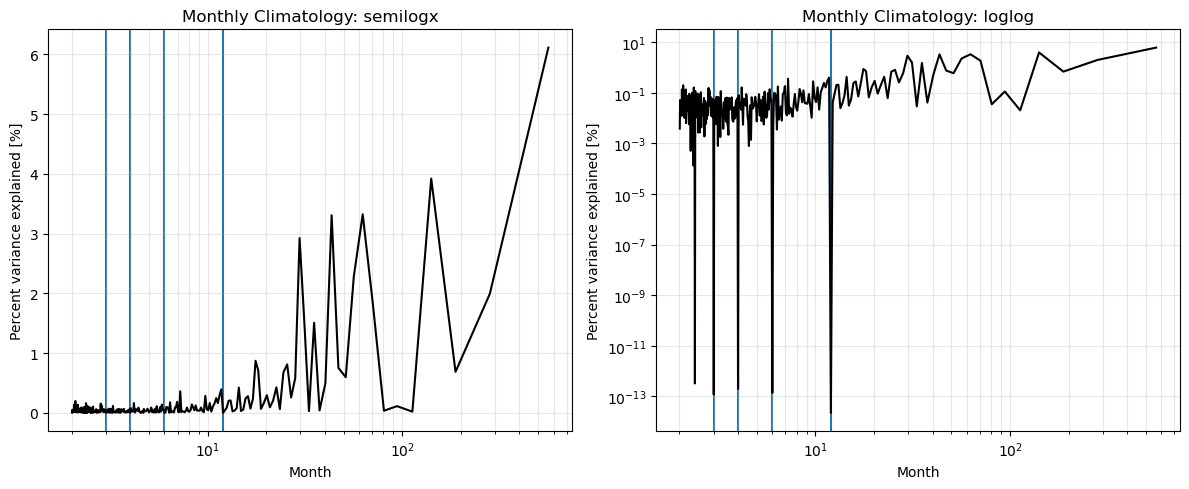

In [39]:
monthly_climatology_mask = (
    np.isfinite(monthly_climatology_periods)
    & (monthly_climatology_periods > 0)
    & (monthly_climatology_percent_variance > 0)
)

clim_periods = monthly_climatology_periods[monthly_climatology_mask]
clim_percent_variance = monthly_climatology_percent_variance[monthly_climatology_mask]

sort_index = np.argsort(clim_periods)
clim_periods = clim_periods[sort_index]
clim_percent_variance = clim_percent_variance[sort_index]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].semilogx(
    clim_periods,
    clim_percent_variance,
    color="k"
)

for period in reference_periods:
    axes[0].axvline(period, zorder=0)

axes[0].set_xlabel("Month")
axes[0].set_ylabel("Percent variance explained [%]")
axes[0].set_title("Monthly Climatology: semilogx")
axes[0].grid(True, which="both", alpha=0.3)


axes[1].loglog(
    clim_periods,
    clim_percent_variance,
    color="k"
)

for period in reference_periods:
    axes[1].axvline(period, zorder=0)

axes[1].set_xlabel("Month")
axes[1].set_ylabel("Percent variance explained [%]")
axes[1].set_title("Monthly Climatology: loglog")
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

#### Harmonic Regression

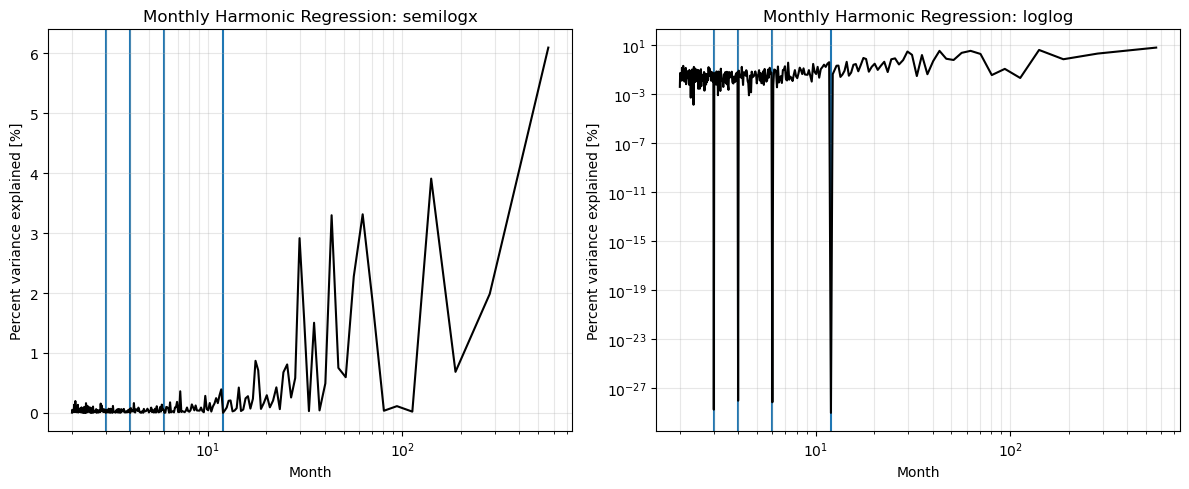

In [40]:
monthly_harmonic_mask = (
    np.isfinite(monthly_harmonic_periods)
    & (monthly_harmonic_periods > 0)
    & (monthly_harmonic_percent_variance > 0)
)

harm_periods = monthly_harmonic_periods[monthly_harmonic_mask]
harm_percent_variance = monthly_harmonic_percent_variance[monthly_harmonic_mask]

sort_index = np.argsort(harm_periods)
harm_periods = harm_periods[sort_index]
harm_percent_variance = harm_percent_variance[sort_index]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].semilogx(
    harm_periods,
    harm_percent_variance,
    color="k"
)

for period in reference_periods:
    axes[0].axvline(period, zorder=0)

axes[0].set_xlabel("Month")
axes[0].set_ylabel("Percent variance explained [%]")
axes[0].set_title("Monthly Harmonic Regression: semilogx")
axes[0].grid(True, which="both", alpha=0.3)


axes[1].loglog(
    harm_periods,
    harm_percent_variance,
    color="k"
)

for period in reference_periods:
    axes[1].axvline(period, zorder=0)

axes[1].set_xlabel("Month")
axes[1].set_ylabel("Percent variance explained [%]")
axes[1].set_title("Monthly Harmonic Regression: loglog")
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

---

## What's next?
After identifying the dominant periods in the anomaly time series using the Fourier spectrum, our next step is to reconstruct the portion of the signal associated with selected periodic components. This allows us to isolate variability at specific timescales that the audience is interested in studying. Here are the tasks we will implement: 

* Select the periodic components of interest
* Apply frequency filtering
* Reconstruct the filtered signal


## Reference

Kalnay, E., Kanamitsu, M., Kistler, R., Collins, W., Deaven, D., Gandin, L., ... & Joseph, D. (2018). The NCEP/NCAR 40-year reanalysis project. In Renewable energy (pp. Vol1_146-Vol1_194). Routledge.

## Acknowledgement

Huge thanks to Juan Diego for providing the code used for the daily harmonic regression method.